<a href="https://colab.research.google.com/github/irajamuller/error_corrections/blob/main/UA3_UA4_Estabilizadores_Bit_flip.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install qiskit qiskit_aer pylatexenc --quiet

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 162.6/162.6 kB 3.5 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.3/9.3 MB 79.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 88.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 67.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.6/54.6 kB 3.0 MB/s eta 0:00:00


In [2]:
# Classes do qiskit
from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister, transpile
from qiskit_aer import AerSimulator, Aer
from qiskit.quantum_info import Statevector
from qiskit.visualization import plot_histogram, array_to_latex

import numpy as np

In [49]:
def create_repetition_code_stabilizers():
    q_codes   = QuantumRegister(3, 'code')
    q_ancilla = QuantumRegister(2, 'ancilla')
    c_syndrome = ClassicalRegister(2, 'syndrome')
    c_outcomes = ClassicalRegister(3, 'outcomes')

    qc = QuantumCircuit(q_codes, q_ancilla, c_syndrome, c_outcomes)

    # ─── 1. CODIFICAÇÃO: |0⟩ → |0_L⟩ = |000⟩ ──────────────────────────
    # Sem portas, pois |0⟩ ⊗ |0⟩ ⊗ |0⟩ já é |000⟩.
    qc.barrier(label='|0>')
    qc.cx(q_codes[0], q_codes[1])   # espalha o bit lógico
    qc.cx(q_codes[0], q_codes[2])   # para os outros qubits físicos

    # ─── 2. INJEÇÃO DE ERRO (Bit-flip no qubit 0) ───────────────────────
    qc.barrier(label='Injeção Erro X')
    qc.x(q_codes[0])

    # ─── 4. MEDIÇÃO DOS ESTABILIZADORES (Portas Clifford) ───────────────
    qc.barrier(label='Estabilizadores')
    qc.reset(q_ancilla[0])
    qc.reset(q_ancilla[1])
    # S₁ = Z₀Z₁  →  ancilla 0
    qc.cx(q_codes[0], q_ancilla[0])
    qc.cx(q_codes[1], q_ancilla[0])
    # S₂ = Z₁Z₂  →  ancilla 1
    qc.cx(q_codes[1], q_ancilla[1])
    qc.cx(q_codes[2], q_ancilla[1])

    qc.measure(q_ancilla, c_syndrome)

    # ─── 5. CORREÇÃO CONDICIONAL (Feed-forward) ─────────────────────────
    # syndrome = 01 (1) → erro no qubit 0
    # syndrome = 11 (3) → erro no qubit 1
    # syndrome = 10 (2) → erro no qubit 2
    qc.barrier(label='Correção')
    with qc.if_test((c_syndrome, 1)):
        qc.x(q_codes[0])
    with qc.if_test((c_syndrome, 3)):
        qc.x(q_codes[1])
    with qc.if_test((c_syndrome, 2)):
        qc.x(q_codes[2])

    # ─── 6. PORTA TRANSVERSAL: X_L · X_L = I_L ─────────────────────────
    qc.barrier(label='Transversal')
    for qubit in q_codes:
        qc.x(qubit)   # primeiro X_L
    for qubit in q_codes:
        qc.x(qubit)   # segundo X_L  →  retorna a |000⟩

    # ─── 7. DECODIFICAÇÃO: |000⟩ → |0⟩ ─────────────────────────────────
    qc.barrier(label='Decodificação')
    qc.cx(q_codes[0], q_codes[2])
    qc.cx(q_codes[0], q_codes[1])

    # ─── 8. MEDIÇÃO FINAL ───────────────────────────────────────────────
    qc.barrier(label='Medição')
    qc.measure(q_codes, c_outcomes)

    # ─── SIMULAÇÃO ──────────────────────────────────────────────────────
    backend = AerSimulator()
    result  = backend.run(transpile(qc, backend), shots=1024).result()
    counts  = result.get_counts()
    print("Contagens brutas (outcomes syndrome):", counts)

    return qc, counts

In [51]:
qc, counts = create_repetition_code_stabilizers()

Contagens brutas (outcomes syndrome): {'000 01': 1024}


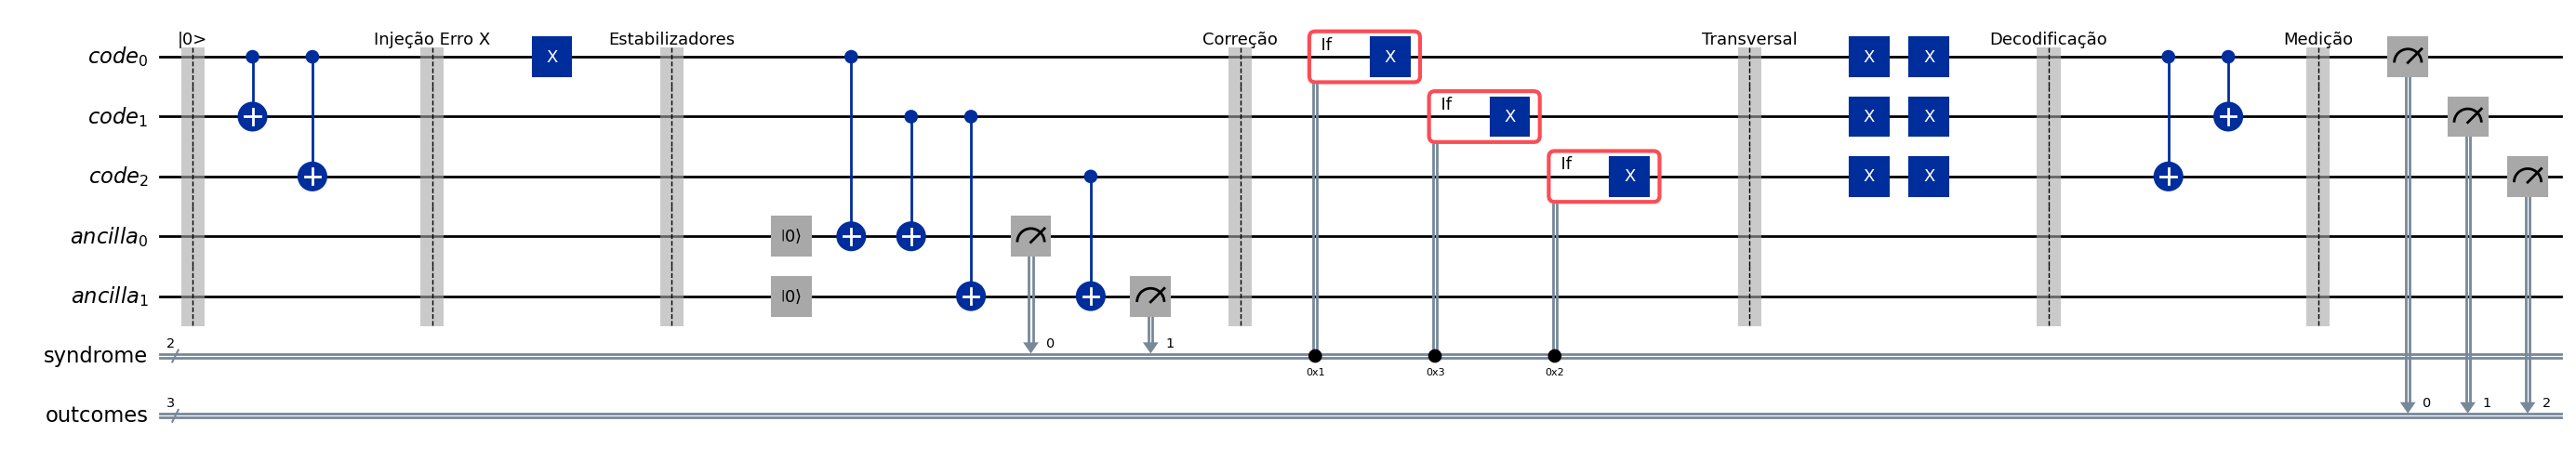

In [38]:
qc.draw('mpl', fold=-1)